# ============================================================
# POWER PLANT ENERGY OUTPUT - REGRESSION PIPELINE
# ============================================================
# Target: PE (Net hourly electrical energy output)
# Features: AT (Temperature), V (Vacuum), AP (Pressure), RH (Humidity)
# ============================================================

In [1]:

# ============================================================
# STEP 1: IMPORT LIBRARIES
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

In [2]:

# ============================================================
# STEP 2: LOAD DATASET
# ============================================================
df = pd.read_csv('Power_Plant_Energy_Output.csv')
print(f"✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")

✅ Dataset loaded: 9568 rows × 5 columns


In [3]:

# ============================================================
# STEP 3: INSPECT DATA
# ============================================================

# Head
print(df.head())


      AT      V       AP     RH      PE
0   8.34  40.77  1010.84  90.01  480.48
1  23.64  58.49  1011.40  74.20  445.75
2  29.74  56.90  1007.15  41.91  438.76
3  19.07  49.69  1007.22  76.79  453.09
4  11.80  40.66  1017.13  97.20  464.43


In [4]:
# Dtypes
print(df.dtypes)


AT    float64
V     float64
AP    float64
RH    float64
PE    float64
dtype: object


In [5]:
# Info
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


In [6]:
# Describe
print(df.describe())


                AT            V           AP           RH           PE
count  9568.000000  9568.000000  9568.000000  9568.000000  9568.000000
mean     19.651231    54.305804  1013.259078    73.308978   454.365009
std       7.452473    12.707893     5.938784    14.600269    17.066995
min       1.810000    25.360000   992.890000    25.560000   420.260000
25%      13.510000    41.740000  1009.100000    63.327500   439.750000
50%      20.345000    52.080000  1012.940000    74.975000   451.550000
75%      25.720000    66.540000  1017.260000    84.830000   468.430000
max      37.110000    81.560000  1033.300000   100.160000   495.760000


In [7]:
# Null values
print(df.isnull().sum())
print(f"\nTotal nulls: {df.isnull().sum().sum()}")


AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

Total nulls: 0


In [8]:
# Duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")



Duplicate rows: 41


In [9]:
# ============================================================
# STEP 4: CLEAN DATA
# ============================================================

# Drop duplicates
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after = len(df)
print(f"Duplicates removed: {before - after}")
print(f"Final shape: {df.shape}")

Duplicates removed: 41
Final shape: (9527, 5)



STEP 5: EXPLORATORY DATA ANALYSIS


/tmp/ipykernel_1436/1254672046.py:18: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df['PE'], vert=True)


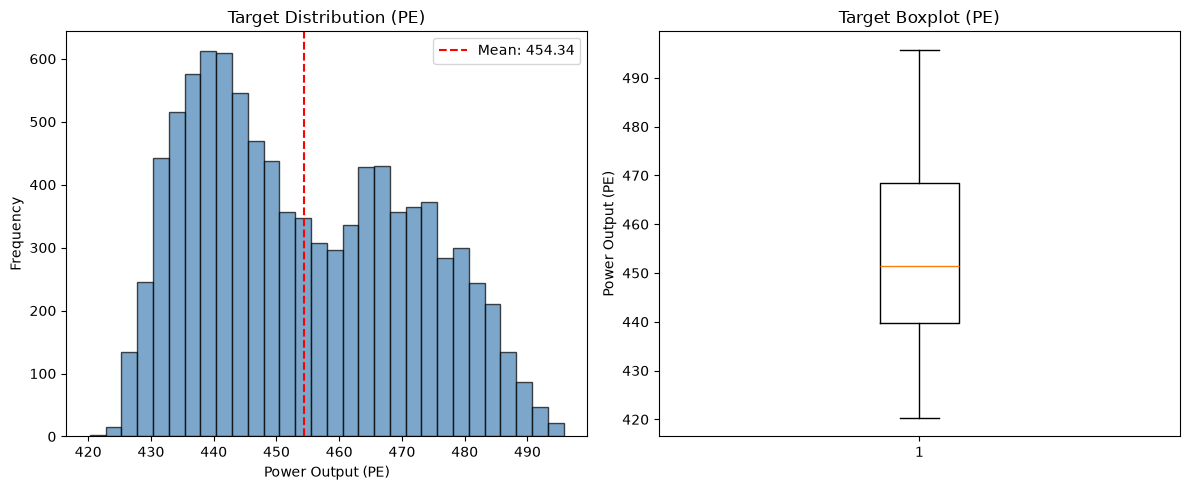

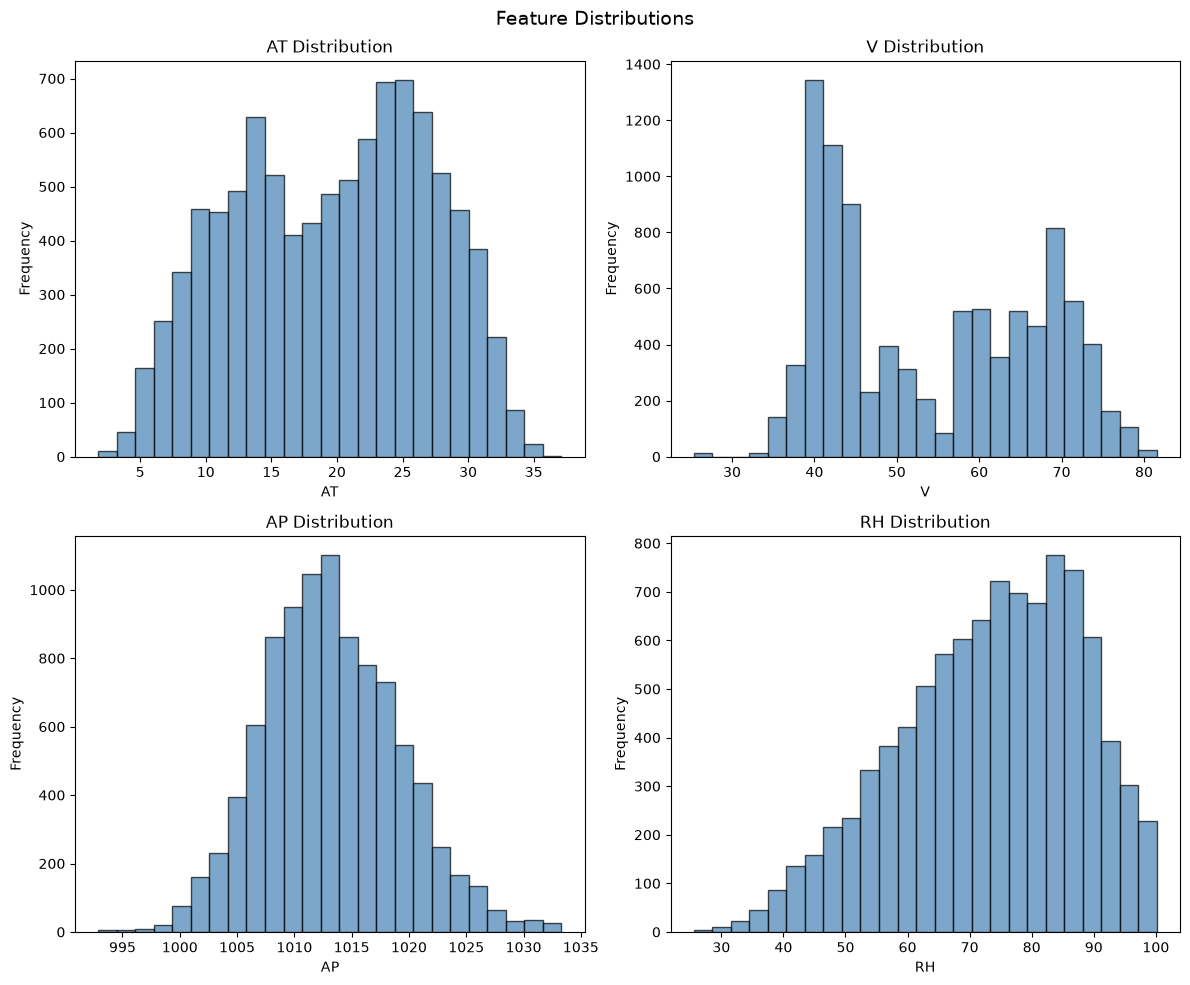

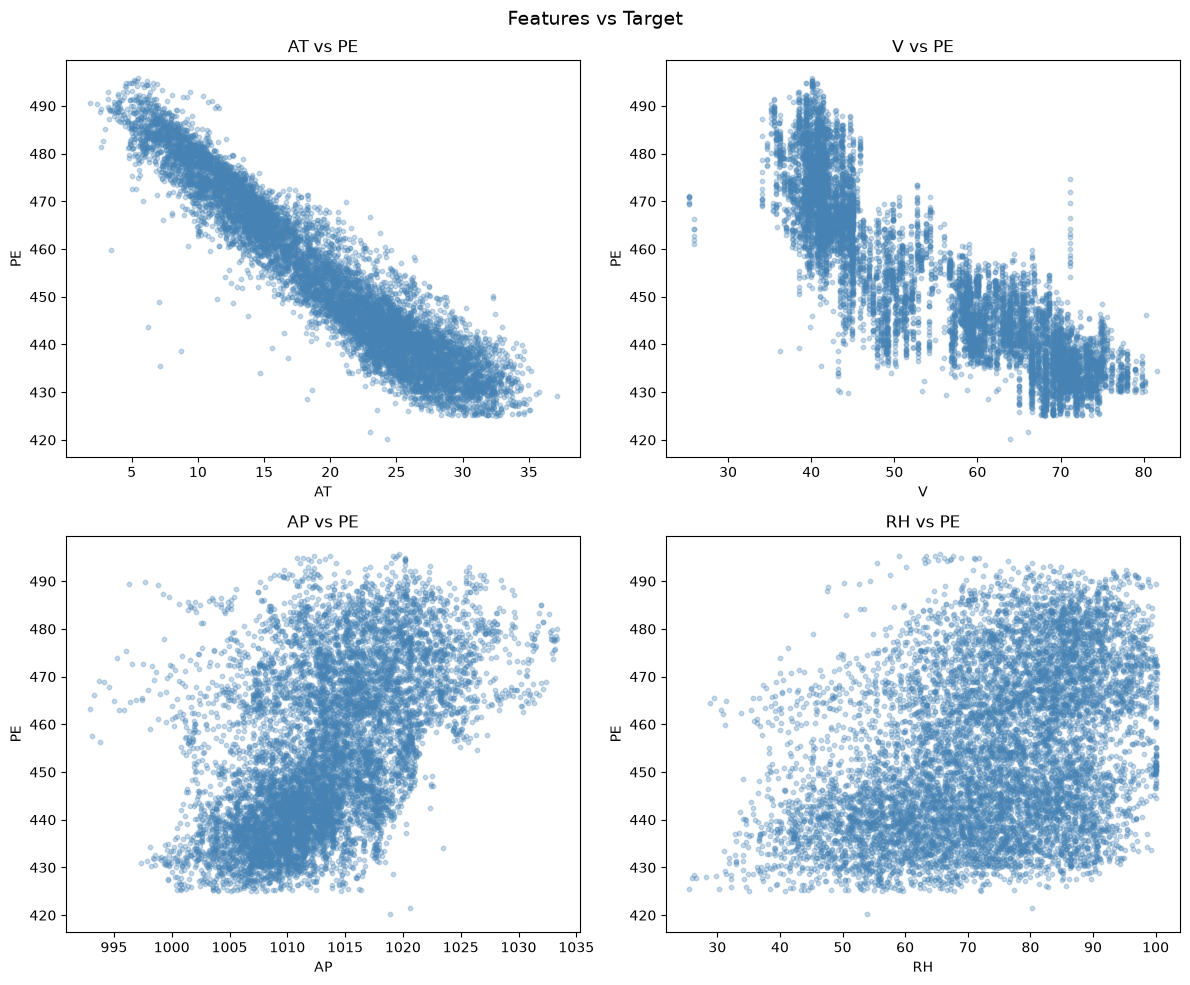

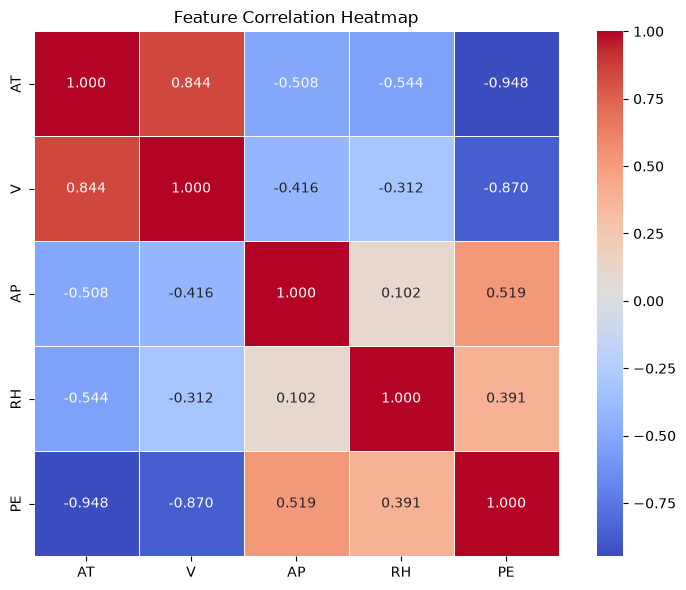

In [10]:

# ============================================================
# STEP 5: EDA (4 plots)
# ============================================================
print("\n" + "="*60)
print("STEP 5: EXPLORATORY DATA ANALYSIS")
print("="*60)

# PLOT 1: Target Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df['PE'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Target Distribution (PE)')
axes[0].set_xlabel('Power Output (PE)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['PE'].mean(), color='red', linestyle='--', label=f"Mean: {df['PE'].mean():.2f}")
axes[0].legend()

axes[1].boxplot(df['PE'], vert=True)
axes[1].set_title('Target Boxplot (PE)')
axes[1].set_ylabel('Power Output (PE)')

plt.tight_layout()
plt.show()

# PLOT 2: Feature Distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
features = ['AT', 'V', 'AP', 'RH']

for idx, feature in enumerate(features):
    ax = axes[idx // 2, idx % 2]
    ax.hist(df[feature], bins=25, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'{feature} Distribution')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')

plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

# PLOT 3: Features vs Target (Scatter)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, feature in enumerate(features):
    ax = axes[idx // 2, idx % 2]
    ax.scatter(df[feature], df['PE'], alpha=0.3, s=10, color='steelblue')
    ax.set_title(f'{feature} vs PE')
    ax.set_xlabel(feature)
    ax.set_ylabel('PE')

plt.suptitle('Features vs Target', fontsize=14)
plt.tight_layout()
plt.show()

# PLOT 4: Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.3f',
            linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [11]:

# ============================================================
# STEP 6: PREPROCESS - SPLIT FEATURES/TARGET + SCALE
# ============================================================
X = df.drop('PE', axis=1)
y = df['PE']
print(f"Features (X): {X.shape}")
print(f"Target (y):   {y.shape}")


Features (X): (9527, 4)
Target (y):   (9527,)


In [12]:
# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)


In [13]:
# ============================================================
# STEP 7: SPLIT DATA INTO TRAIN/TEST
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test set:  {X_test.shape[0]} samples")


Train set: 7621 samples
Test set:  1906 samples


In [14]:
# ============================================================
# STEP 8 & 9: DEFINE, TRAIN & EVALUATE MODELS
# ============================================================

# Define all 6 models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'SVR': SVR(kernel='rbf'),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}
print(f"\n{'Model':<25} {'R²':>8} {'MAE':>8} {'RMSE':>8}")
print("-" * 55)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results[name] = {'R2': r2, 'MAE': mae, 'RMSE': rmse}
    print(f"{name:<25} {r2:>8.4f} {mae:>8.4f} {rmse:>8.4f}")


Model                           R²      MAE     RMSE
-------------------------------------------------------
Linear Regression           0.9308   3.6630   4.5709
Decision Tree               0.9330   3.1071   4.4956
Random Forest               0.9651   2.3294   3.2458
SVR                         0.9425   3.1879   4.1659
KNN                         0.9520   2.7676   3.8068
Gradient Boosting           0.9523   2.9176   3.7958


In [15]:
# ============================================================
# STEP 10: FINAL RESULTS TABLE
# ============================================================
results_df = pd.DataFrame(results).T
results_df = results_df.reset_index().rename(columns={'index': 'Model'})
results_df = results_df.sort_values('R2', ascending=False).reset_index(drop=True)
results_df.index += 1

best = results_df.loc[1, 'Model']
results_df['Best'] = results_df['Model'].apply(lambda x: '⭐' if x == best else '')

print(f"\n🏆 Best Model: {best} (R² = {results_df.loc[1, 'R2']:.4f})")
print()
print(results_df.to_string())



🏆 Best Model: Random Forest (R² = 0.9651)

               Model        R2       MAE      RMSE Best
1      Random Forest  0.965091  2.329359  3.245799    ⭐
2  Gradient Boosting  0.952259  2.917625  3.795754     
3                KNN  0.951981  2.767581  3.806786     
4                SVR  0.942493  3.187939  4.165921     
5      Decision Tree  0.933032  3.107099  4.495593     
6  Linear Regression  0.930770  3.662981  4.570863     


In [16]:
# Save to CSV
results_df.to_csv('power_plant_model_comparison.csv', index=False)
print("\n✅ Results saved to: power_plant_model_comparison.csv")


✅ Results saved to: power_plant_model_comparison.csv
